## Thư viện

In [71]:
import os
import re
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Function
from tqdm import tqdm

## Config

In [72]:
# ======================
# CONFIG
# ======================

DATA_DIR = "Data"

SOURCE_DOMAIN = "N15_M01_F10"
TARGET_DOMAIN = "N09_M07_F10"

WINDOW_SIZE = 2048
STRIDE = 512

BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

Device: cpu


## Label map

In [73]:
label_map = {
    "K001": 0,   # normal
    "KA04": 1,   # outer race
    "KI04": 2    # inner race
}

id2label = {v:k for k,v in label_map.items()}

## Read .mat

In [74]:
import scipy.io as sio
import numpy as np


def extract_signal(mat_path):

    try:
        mat = sio.loadmat(mat_path)

        # key chính
        main_key = [
            k for k in mat.keys()
            if not k.startswith("__")
        ][0]

        data = mat[main_key]

        # field Y
        Y = data["Y"][0, 0]

        signal = None

        # tìm vibration_1
        for item in Y[0]:

            try:
                name = item["Name"][0]

                if name == "vibration_1":

                    signal = item["Data"]

                    signal = np.array(
                        signal
                    ).squeeze()

                    break

            except:
                pass

        if signal is None:
            return None

        signal = signal.flatten()

        if len(signal) < 1000:
            return None

        return signal.astype(np.float32)

    except Exception as e:
        print("Read error:", mat_path)
        print(e)
        return None

In [75]:
import scipy.io as sio
import numpy as np

sample_file = r"c:\Users\Laptop\Downloads\BTL2\Data\K001\N09_M07_F10_K001_1.mat"

mat = sio.loadmat(sample_file)

main_key = [k for k in mat.keys() if not k.startswith("__")][0]

data = mat[main_key]

print("main key:", main_key)
print("data shape:", data.shape)
print("dtype:", data.dtype)

Y = data["Y"][0, 0]

print("\n===== Y INFO =====")
print("type:", type(Y))

if isinstance(Y, np.ndarray):
    print("shape:", Y.shape)
    print("dtype:", Y.dtype)

    try:
        print("first element type:", type(Y.flat[0]))
    except Exception as e:
        print(e)

print("\nY preview:")
try:
    print(Y)
except:
    print("cannot print")

main key: N09_M07_F10_K001_1
data shape: (1, 1)
dtype: [('Info', 'O'), ('X', 'O'), ('Y', 'O'), ('Description', 'O')]

===== Y INFO =====
type: <class 'numpy.ndarray'>
shape: (1, 7)
dtype: [('Name', 'O'), ('Type', 'O'), ('Data', 'O'), ('Unit', 'O'), ('Raster', 'O'), ('Device', 'O'), ('XIndex', 'O'), ('DownSampling', 'O'), ('Description', 'O'), ('DisplayIdentifier', 'O'), ('Path', 'O'), ('Flags', 'O'), ('Min', 'O'), ('Max', 'O'), ('MinWeak', 'O'), ('MaxWeak', 'O')]
first element type: <class 'numpy.void'>

Y preview:
[[(array(['force'], dtype='<U5'), array([[4]], dtype=int32), array([[927.26279233, 919.93857359, 949.54062435, ..., 927.56796811,
          929.3990228 , 927.87314389]], shape=(1, 16008)), array([], dtype='<U1'), array(['Mech_4kHz'], dtype='<U9'), array(['Platform'], dtype='<U8'), array([[1]], dtype=int32), array([[1]], dtype=int32), array([], dtype='<U1'), array([], dtype='<U1'), array(['Model Root/Einggangssignal'], dtype='<U26'), array([[2]], dtype=int32), array([[-1.7976

In [76]:
sample_file = r"c:\Users\Laptop\Downloads\BTL2\Data\K001\N09_M07_F10_K001_1.mat"

sig = extract_signal(sample_file)

print(sig is None)

if sig is not None:
    print(sig.shape)
    print(len(sig))
    print(sig[:10])

False
(256823,)
256823
[ 0.06408691 -0.12207031  0.11291504  0.38452148  0.0793457   0.43945312
  0.07629395 -0.5218506   0.01220703 -0.09460449]


## Load dataset

In [77]:
import os
import numpy as np

# =========================
# DATASET PATH
# =========================
DATA_DIR = r"c:\Users\Laptop\Downloads\BTL2\Data"

print("Dataset folders:")
print(os.listdir(DATA_DIR))

# =========================
# LABEL MAP
# =========================
label_map = {
    "K001": 0,
    "KA04": 1,
    "KI04": 2
}

# =========================
# DOMAIN
# =========================
SOURCE_DOMAIN = "N15_M07_F10"
TARGET_DOMAIN = "N15_M01_F10"

Dataset folders:
['K001', 'KA04', 'KI04']


In [78]:
import os

for folder in ["K001", "KA04", "KI04"]:

    folder_path = os.path.join(DATA_DIR, folder)

    print(f"\n===== {folder} =====")

    files = [
        f for f in os.listdir(folder_path)
        if f.endswith(".mat")
    ]

    for f in files[:20]:
        print(f)


===== K001 =====
N09_M07_F10_K001_1.mat
N09_M07_F10_K001_10.mat
N09_M07_F10_K001_11.mat
N09_M07_F10_K001_12.mat
N09_M07_F10_K001_13.mat
N09_M07_F10_K001_14.mat
N09_M07_F10_K001_15.mat
N09_M07_F10_K001_16.mat
N09_M07_F10_K001_17.mat
N09_M07_F10_K001_18.mat
N09_M07_F10_K001_19.mat
N09_M07_F10_K001_2.mat
N09_M07_F10_K001_20.mat
N09_M07_F10_K001_3.mat
N09_M07_F10_K001_4.mat
N09_M07_F10_K001_5.mat
N09_M07_F10_K001_6.mat
N09_M07_F10_K001_7.mat
N09_M07_F10_K001_8.mat
N09_M07_F10_K001_9.mat

===== KA04 =====

===== KI04 =====


In [79]:
import os

for folder in ["KA04", "KI04"]:

    folder_path = os.path.join(DATA_DIR, folder)

    print(f"\n===== {folder} =====")

    for root, dirs, files in os.walk(folder_path):

        print("ROOT:", root)
        print("DIRS:", dirs[:5])
        print("FILES:", files[:10])
        print("-" * 50)


===== KA04 =====
ROOT: c:\Users\Laptop\Downloads\BTL2\Data\KA04
DIRS: ['KA04']
FILES: []
--------------------------------------------------
ROOT: c:\Users\Laptop\Downloads\BTL2\Data\KA04\KA04
DIRS: []
FILES: ['KA04.pdf', 'measuring_log_KA04.pdf', 'N09_M07_F10_KA04_1.mat', 'N09_M07_F10_KA04_10.mat', 'N09_M07_F10_KA04_11.mat', 'N09_M07_F10_KA04_12.mat', 'N09_M07_F10_KA04_13.mat', 'N09_M07_F10_KA04_14.mat', 'N09_M07_F10_KA04_15.mat', 'N09_M07_F10_KA04_16.mat']
--------------------------------------------------

===== KI04 =====
ROOT: c:\Users\Laptop\Downloads\BTL2\Data\KI04
DIRS: ['KI04']
FILES: []
--------------------------------------------------
ROOT: c:\Users\Laptop\Downloads\BTL2\Data\KI04\KI04
DIRS: []
FILES: ['KI04.pdf', 'measuring_log_KI04.pdf', 'N09_M07_F10_KI04_1.mat', 'N09_M07_F10_KI04_10.mat', 'N09_M07_F10_KI04_11.mat', 'N09_M07_F10_KI04_12.mat', 'N09_M07_F10_KI04_13.mat', 'N09_M07_F10_KI04_14.mat', 'N09_M07_F10_KI04_15.mat', 'N09_M07_F10_KI04_16.mat']
-----------------------

In [80]:
import os

for folder in ["K001", "KA04", "KI04"]:

    print(f"\n===== {folder} =====")

    folder_path = os.path.join(DATA_DIR, folder)

    count = 0

    for root, dirs, files in os.walk(folder_path):

        for file in files:

            if file.endswith(".mat"):
                print(file)

                count += 1

                if count >= 30:
                    break


===== K001 =====
N09_M07_F10_K001_1.mat
N09_M07_F10_K001_10.mat
N09_M07_F10_K001_11.mat
N09_M07_F10_K001_12.mat
N09_M07_F10_K001_13.mat
N09_M07_F10_K001_14.mat
N09_M07_F10_K001_15.mat
N09_M07_F10_K001_16.mat
N09_M07_F10_K001_17.mat
N09_M07_F10_K001_18.mat
N09_M07_F10_K001_19.mat
N09_M07_F10_K001_2.mat
N09_M07_F10_K001_20.mat
N09_M07_F10_K001_3.mat
N09_M07_F10_K001_4.mat
N09_M07_F10_K001_5.mat
N09_M07_F10_K001_6.mat
N09_M07_F10_K001_7.mat
N09_M07_F10_K001_8.mat
N09_M07_F10_K001_9.mat
N15_M01_F10_K001_1.mat
N15_M01_F10_K001_10.mat
N15_M01_F10_K001_11.mat
N15_M01_F10_K001_12.mat
N15_M01_F10_K001_13.mat
N15_M01_F10_K001_14.mat
N15_M01_F10_K001_15.mat
N15_M01_F10_K001_16.mat
N15_M01_F10_K001_17.mat
N15_M01_F10_K001_18.mat

===== KA04 =====
N09_M07_F10_KA04_1.mat
N09_M07_F10_KA04_10.mat
N09_M07_F10_KA04_11.mat
N09_M07_F10_KA04_12.mat
N09_M07_F10_KA04_13.mat
N09_M07_F10_KA04_14.mat
N09_M07_F10_KA04_15.mat
N09_M07_F10_KA04_16.mat
N09_M07_F10_KA04_17.mat
N09_M07_F10_KA04_18.mat
N09_M07_F10_KA0

In [81]:
# ==========================
# Cấu hình miền dữ liệu
# ==========================
SOURCE_DOMAIN = "N15_M01_F10"
TARGET_DOMAIN = "N09_M07_F10"

# ==========================
# Hàm tạo sliding windows
# ==========================
def create_windows(signal, window_size, stride):

    windows = []

    # Chia tín hiệu thành các cửa sổ
    for i in range(
        0,
        len(signal) - window_size + 1,
        stride
    ):

        window = signal[
            i:i + window_size
        ]

        windows.append(window)

    return np.array(
        windows,
        dtype=np.float32
    )


# ==========================
# Khởi tạo dữ liệu
# ==========================
X_source = []
y_source = []

X_target = []
y_target = []


# ==========================
# Đọc dữ liệu
# ==========================
for folder in label_map.keys():

    folder_path = os.path.join(
        DATA_DIR,
        folder
    )

    label = label_map[folder]

    print(f"\n===== {folder} =====")

    for root, dirs, files in os.walk(folder_path):

        for file in files:

            # Chỉ lấy file .mat
            if not file.endswith(".mat"):
                continue

            file_path = os.path.join(
                root,
                file
            )

            print("\nFILE:", file)

            # Đọc tín hiệu
            signal = extract_signal(file_path)

            print(
                "signal none?",
                signal is None
            )

            if signal is None:
                continue

            print(
                "signal len:",
                len(signal)
            )

            # Tạo sliding windows
            windows = create_windows(
                signal,
                WINDOW_SIZE,
                STRIDE
            )

            print(
                "windows shape:",
                windows.shape
            )

            # Lấy tên domain
            domain_name = "_".join(
                file.split("_")[:3]
            )

            print(
                "domain:",
                domain_name
            )

            # Miền nguồn
            if domain_name == SOURCE_DOMAIN:

                X_source.extend(windows)

                y_source.extend(
                    [label] * len(windows)
                )

                print("-> SOURCE")

            # Miền đích
            elif domain_name == TARGET_DOMAIN:

                X_target.extend(windows)

                y_target.extend(
                    [label] * len(windows)
                )

                print("-> TARGET")


# ==========================
# Chuyển sang numpy array
# ==========================
X_source = np.array(
    X_source,
    dtype=np.float32
)

y_source = np.array(
    y_source
)

X_target = np.array(
    X_target,
    dtype=np.float32
)

y_target = np.array(
    y_target
)


# ==========================
# Kiểm tra kết quả
# ==========================
print("\n========== FINAL ==========")

print("X_source:", X_source.shape)
print("y_source:", y_source.shape)

print("X_target:", X_target.shape)
print("y_target:", y_target.shape)


===== K001 =====

FILE: N09_M07_F10_K001_1.mat
signal none? False
signal len: 256823
windows shape: (498, 2048)
domain: N09_M07_F10
-> TARGET

FILE: N09_M07_F10_K001_10.mat
signal none? False
signal len: 256608
windows shape: (498, 2048)
domain: N09_M07_F10
-> TARGET

FILE: N09_M07_F10_K001_11.mat
signal none? False
signal len: 256096
windows shape: (497, 2048)
domain: N09_M07_F10
-> TARGET

FILE: N09_M07_F10_K001_12.mat
signal none? False
signal len: 256000
windows shape: (497, 2048)
domain: N09_M07_F10
-> TARGET

FILE: N09_M07_F10_K001_13.mat
signal none? False
signal len: 256000
windows shape: (497, 2048)
domain: N09_M07_F10
-> TARGET

FILE: N09_M07_F10_K001_14.mat
signal none? False
signal len: 256002
windows shape: (497, 2048)
domain: N09_M07_F10
-> TARGET

FILE: N09_M07_F10_K001_15.mat
signal none? False
signal len: 256001
windows shape: (497, 2048)
domain: N09_M07_F10
-> TARGET

FILE: N09_M07_F10_K001_16.mat
signal none? False
signal len: 256001
windows shape: (497, 2048)
domai

In [82]:
print("X_source:", X_source.shape)
print("X_target:", X_target.shape)

print("y_source:", y_source.shape)
print("y_target:", y_target.shape)

X_source: (29838, 2048)
X_target: (29866, 2048)
y_source: (29838,)
y_target: (29866,)


## Train/Test split

In [83]:
X_train, X_val, y_train, y_val = train_test_split(
    X_source,
    y_source,
    test_size=0.2,
    random_state=42,
    stratify=y_source
)

## Dataset

In [84]:
class BearingDataset(Dataset):

    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)

        if y is not None:
            self.y = torch.tensor(y, dtype=torch.long)
        else:
            self.y = None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        if self.y is None:
            return self.X[idx]

        return self.X[idx], self.y[idx]

## DataLoader

In [85]:
train_loader = DataLoader(
    BearingDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    BearingDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

target_loader = DataLoader(
    BearingDataset(X_target, y_target),
    batch_size=BATCH_SIZE,
    shuffle=True
)

## Gradient Reversal

In [86]:
class GRL(Function):

    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None


def grad_reverse(x, alpha=1.0):
    return GRL.apply(x, alpha)

## model

In [87]:
class SLARDA(nn.Module):

    def __init__(self):

        super().__init__()

        self.feature = nn.Sequential(
            nn.Conv1d(1,16,5,padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16,32,5,padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32,64,5,padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,3)
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,2)
        )

    def forward(self, x, alpha=1.0):

        feat = self.feature(x)
        feat = feat.squeeze(-1)

        cls_out = self.classifier(feat)

        rev_feat = grad_reverse(feat, alpha)
        dom_out = self.domain_classifier(rev_feat)

        return cls_out, dom_out

## training

In [88]:
model = SLARDA().to(DEVICE)
criterion_cls = nn.CrossEntropyLoss()
criterion_domain = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    target_iter = iter(target_loader)
    for x_s, y_s in tqdm(train_loader):
        try:
            x_t, y_t = next(target_iter)
        except:
            target_iter = iter(target_loader)
            x_t, y_t = next(target_iter)
        x_s = x_s.to(DEVICE)
        y_s = y_s.to(DEVICE)
        x_t = x_t.to(DEVICE)
        optimizer.zero_grad()
        cls_out, dom_s = model(x_s)
        _, dom_t = model(x_t)
        cls_loss = criterion_cls(cls_out, y_s)
        domain_source_label = torch.zeros(
            len(x_s),
            dtype=torch.long
        ).to(DEVICE)
        domain_target_label = torch.ones(
            len(x_t),
            dtype=torch.long
        ).to(DEVICE)
        dom_loss_s = criterion_domain(
            dom_s,
            domain_source_label
        )
        dom_loss_t = criterion_domain(
            dom_t,
            domain_target_label
        )
        loss = cls_loss + 0.2*(dom_loss_s + dom_loss_t)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {total_loss/len(train_loader):.4f}"
    )

100%|██████████| 373/373 [00:55<00:00,  6.76it/s]


Epoch [1/20] Loss: 0.4051


100%|██████████| 373/373 [02:31<00:00,  2.46it/s]


Epoch [2/20] Loss: 0.2714


100%|██████████| 373/373 [03:10<00:00,  1.96it/s]


...

Epoch [18/20] Loss: 0.2816


100%|██████████| 373/373 [00:27<00:00, 13.34it/s]


Epoch [19/20] Loss: 0.2793


100%|██████████| 373/373 [00:28<00:00, 13.26it/s]

Epoch [20/20] Loss: 0.2789


## Đánh giá 

In [94]:
model.eval()

preds = []
labels = []

with torch.no_grad():

    for x, y in target_loader:

        x = x.to(DEVICE)

        out, _ = model(x)

        pred = torch.argmax(out, dim=1)

        preds.extend(pred.cpu().numpy())
        labels.extend(y.numpy())

acc = accuracy_score(labels, preds)

print("Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(labels, preds))

Accuracy: 0.9997321368780553

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9945
           1       1.00      1.00      1.00      9941
           2       1.00      1.00      1.00      9980

    accuracy                           1.00     29866
   macro avg       1.00      1.00      1.00     29866
weighted avg       1.00      1.00      1.00     29866



## matrix 

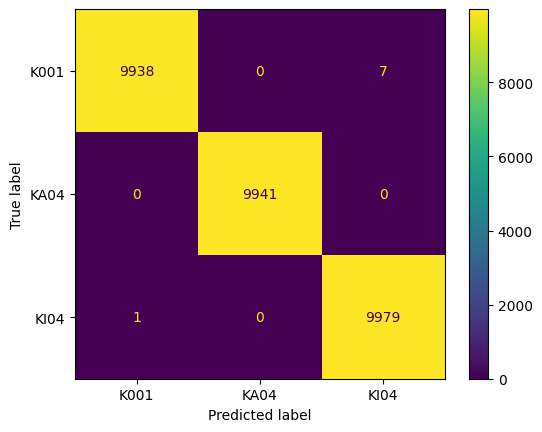

In [95]:
cm = confusion_matrix(labels, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["K001","KA04","KI04"]
)

disp.plot()
plt.show()

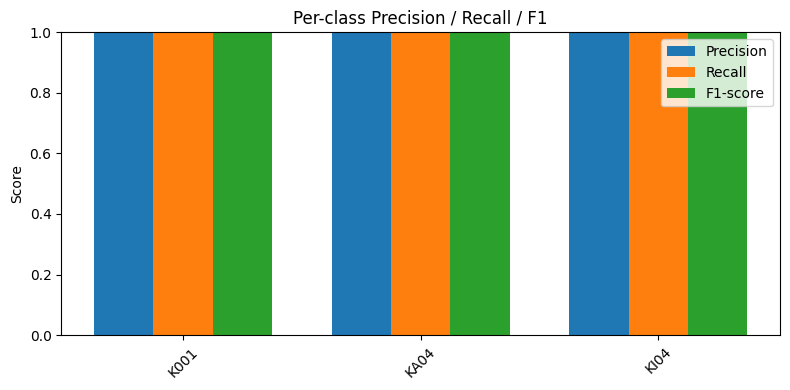

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

labels_order = ["K001", "KA04", "KI04"]

cm = confusion_matrix(labels, preds)


precision = precision_score(labels, preds, average=None, zero_division=0)
recall = recall_score(labels, preds, average=None, zero_division=0)
f1 = f1_score(labels, preds, average=None, zero_division=0)

x = np.arange(len(labels_order))
width = 0.25

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width, precision, width, label="Precision")
ax.bar(x, recall, width, label="Recall")
ax.bar(x + width, f1, width, label="F1-score")
ax.set_xticks(x)
ax.set_xticklabels(labels_order, rotation=45)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Per-class Precision / Recall / F1")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# SENSITIVITY OF λ
# ==========================================

lambda_values = [0.001, 0.01, 0.1, 0.2, 0.5, 1, 10]
lambda_results = []

for lam in lambda_values:

    print(f"\n========== λ = {lam} ==========")

    # ======================================
    # RESET MODEL
    # ======================================
    model = SLARDA().to(DEVICE)

    criterion_cls = nn.CrossEntropyLoss()
    criterion_domain = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR
    )

    # ======================================
    # TRAIN
    # ======================================
    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0

        target_iter = iter(target_loader)

        for x_s, y_s in tqdm(train_loader):

            try:
                x_t, _ = next(target_iter)

            except:
                target_iter = iter(target_loader)
                x_t, _ = next(target_iter)

            x_s = x_s.to(DEVICE)
            y_s = y_s.to(DEVICE)
            x_t = x_t.to(DEVICE)

            optimizer.zero_grad()

            # ==========================
            # FORWARD
            # ==========================
            cls_out, dom_s = model(x_s)
            _, dom_t = model(x_t)

            # ==========================
            # CLASSIFICATION LOSS
            # ==========================
            cls_loss = criterion_cls(
                cls_out,
                y_s
            )

            # ==========================
            # DOMAIN LABEL
            # ==========================
            domain_source_label = torch.zeros(
                len(x_s),
                dtype=torch.long
            ).to(DEVICE)

            domain_target_label = torch.ones(
                len(x_t),
                dtype=torch.long
            ).to(DEVICE)

            # ==========================
            # DOMAIN LOSS
            # ==========================
            dom_loss_s = criterion_domain(
                dom_s,
                domain_source_label
            )

            dom_loss_t = criterion_domain(
                dom_t,
                domain_target_label
            )

            domain_loss = dom_loss_s + dom_loss_t

            # ==========================
            # TOTAL LOSS
            # λ sensitivity here
            # ==========================
            loss = cls_loss + lam * domain_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Loss: {total_loss/len(train_loader):.4f}"
        )

    # ======================================
    # VALIDATION
    # ======================================
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x_val, y_val in val_loader:

            x_val = x_val.to(DEVICE)
            y_val = y_val.to(DEVICE)

            pred, _ = model(x_val)

            pred = pred.argmax(dim=1)

            correct += (pred == y_val).sum().item()
            total += y_val.size(0)

    acc = 100 * correct / total

    lambda_results.append(acc)

    print(f"Accuracy = {acc:.2f}%")

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    lambda_values,
    lambda_results,
    marker='o'
)

plt.xscale("log")

plt.xlabel("λ")
plt.ylabel("Accuracy (%)")
plt.title("Sensitivity Analysis of λ")

plt.grid(True)

for x, y in zip(lambda_values, lambda_results):
    plt.text(x, y + 0.2, f"{y:.2f}")

plt.show()

# ==========================================
# PRINT RESULT
# ==========================================

print("\n===== FINAL RESULT =====")

for lam, acc in zip(lambda_values, lambda_results):
    print(f"λ={lam:<5} -> {acc:.2f}%")


========== λ = 0.001 ==========


100%|██████████| 373/373 [00:28<00:00, 13.01it/s]


Epoch [1/20] Loss: 0.1457


100%|██████████| 373/373 [00:28<00:00, 13.23it/s]


Epoch [2/20] Loss: 0.0004


...

100%|██████████| 373/373 [00:31<00:00, 11.80it/s]


Epoch [13/20] Loss: 0.0000


100%|██████████| 373/373 [00:33<00:00, 11.07it/s]


Epoch [14/20] Loss: 0.0000


 26%|██▋       | 98/373 [00:08<00:20, 13.43it/s]

## demo

True label: K001
Predicted : K001


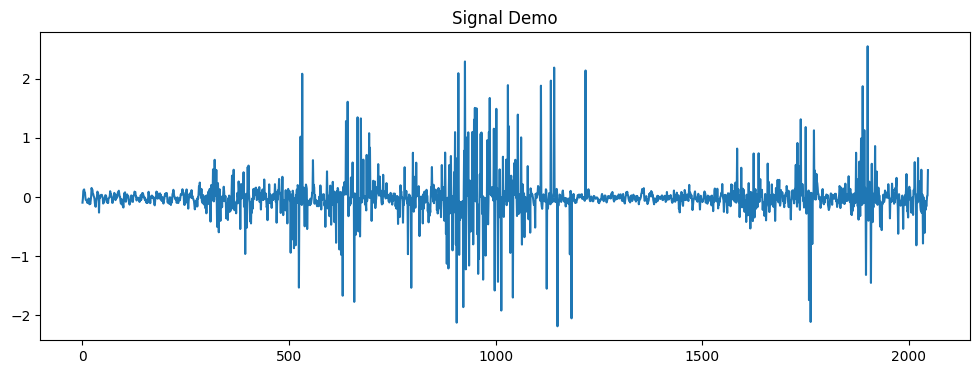

In [96]:
idx = random.randint(0, len(X_target)-1)

sample = torch.tensor(
    X_target[idx],
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0).to(DEVICE)

model.eval()

with torch.no_grad():

    out, _ = model(sample)

pred = torch.argmax(out, dim=1).item()

print("True label:", id2label[y_target[idx]])
print("Predicted :", id2label[pred])

plt.figure(figsize=(12,4))
plt.plot(X_target[idx])
plt.title("Signal Demo")
plt.show()

## Real-world prediction

In [ ]:
# Thực tế: dự đoán một file .mat mới
sample_file = r"c:\Users\Laptop\Downloads\BTL2\Data\K001\N09_M07_F10_K001_1.mat"
signal = extract_signal(sample_file)

if signal is None:
    print("Không đọc được tín hiệu từ file:", sample_file)
else:
    print("Loaded signal shape:", signal.shape)
    windows = create_windows(signal, WINDOW_SIZE, STRIDE)
    print("Created windows:", windows.shape)

    model.eval()
    preds = []
    probs = []

    with torch.no_grad():
        for window in windows:
            x = torch.tensor(window, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
            out, _ = model(x)
            prob = torch.softmax(out, dim=1)[0].cpu().numpy()
            pred = int(out.argmax(dim=1).item())
            preds.append(pred)
            probs.append(prob)

    preds = np.array(preds)
    counts = np.bincount(preds, minlength=len(label_map))
    pred_mode = int(np.argmax(counts))

    print("Prediction counts:")
    for i, count in enumerate(counts):
        print(f"  {id2label[i]}: {count}")

    print("Final predicted label:", id2label[pred_mode])
    print("Sample confidence for final label:", np.mean([p[pred_mode] for p in probs]))

    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar([id2label[i] for i in range(len(counts))], counts)
    ax.set_title("Prediction distribution across windows")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()